#### Name:  

# PHYS 230 Lab Assignment 18

### Monday, April 13, 2026: Chapter 10.2
- Monte Carlo Integration 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt
import random 

## The problem: let's use Monte Carlo methods to evaluate the integral below. 
$$ f(x) = -x^3 +6x^2 -x+17 $$
over the range of $ -2 \leq x \leq 5$

## Part 1: "Hit-or-miss" Monte Carlo Method 

#### Step 1: Make a plot of the function to get an idea of what it looks like. 

(**Hint:** After plotting, look at the $y$-axis and determine a reasonable $y_{\text{max}}$ for the axis limit and limit the axis between 0 and this determined value. This will help to define your area for the method.)

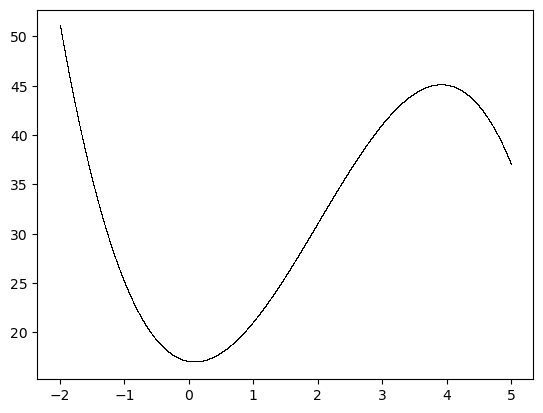

In [11]:
def function(x):
    return -x**3 + 6*(x**2) - x + 17

N = 10000
a,b = -2,5
x_array = np.linspace(a,b,N)

plt.plot(x_array,function(x_array), ",k")
plt.show()

#### Step 2: Use your graph from step 1 to define the area over which you're evaluating your integral, and apply the "hit-or-miss" method of Monte Carlo integration for 10,000 points. Be sure to run the code a few times to get a sense of the average value returned. 

In [36]:
Area = (b-a)*function(a) # base * height

#For loop function
def MC_hit(a,b,N,f):
    k = 0   #hit-or-miss count
    for i in range(N):
        x = a + (b-a)*random.random()
        y = function(a)*random.random()
        if y<function(x):   #checks if our point is inside
            k+=1
    return k
        
Integral = MC_hit(a,b,N,function)*Area/N    #Final Value

print("Integral is", Integral,"u^2")

Integral is 221.3757 u^2


#### Step 3: You can fairly easily solve this integral by hand. Using code, evaluate the true integral below and compare it to your result from step 2.  

In [16]:
def integrated(x):
    return -(x**4)/4 + 2*(x**3) - (x**2)/2 + 17*x

a,b = -2,5
Actual_Int = integrated(b)-integrated(a)

print("Actual Answer is", Actual_Int,"u^2")

Actual Answer is 222.25 u^2


#### Step 4: Try evaluating again using both fewer and more points (make sure you show both results). What do you notice about your result? What do you notice about these different results as you run the code multiple times? [To be really complete, try running for a variety of fewer and more points]

In [37]:
#defining constants
a,b = -2,5                  #Defining bounds
Area = (b-a)*function(a)    #base*height = area

#Printing results
print("Integral Results:")
for N in [1000,10000,100000]:
    Integral = MC_hit(a,b,N,function)*Area/N
    print(N,"points with Monte Carlo method resulting in", Integral, "as the integral result.")

Integral Results:
1000 points with Monte Carlo method resulting in 228.837 as the integral result.
10000 points with Monte Carlo method resulting in 222.5895 as the integral result.
100000 points with Monte Carlo method resulting in 221.10795 as the integral result.


## Part 2: Mean Value Method 

Let's evaluate the same integral using the mean value method instead. 

#### Step 1: Define the function `f(x)` of the integrand

In [ ]:
#defining f(x)
def f(x):
    return -x**3 + 6*x**2 - x + 17

#### Step 2: Create a a loop with $N=10,000$ points to solve for the integral using the mean value method. 

In [38]:
#for loop
a,b = -2,5          #Bounds of the integral
N = 10000           #Number of points
L = (b-a)           #Area of the bounding box
I = 0               #Initializing integral

for i in range(N):
    x = a + (b-a)*random.random()
    I += L/(N) * f(x)

#printing results
print("Integral = ", I)

Integral =  221.90841606467907


#### Step 3: In a markdown cell, compare these results with the "hit-or-miss" method from above. What can you conclude about accuracy? speed? To really evaluate this, be sure to run each method with the same number of points multiple times to see the variation in the result. 

As discussed in class both methods error is proportional to $N^{-1/2}$, so their error should be around the same. However in ease of coding I found that the Mean Value Method was much quicker to code. The large difference between the methods is that the hit/miss method is just counting points that fall under the curve, while the mean value method uses the average of the function to calculate the integral.